# Image Transformation Pipeline with PyTorch
# Part 3: Complete Pipeline

This notebook builds full training/validation transformation pipelines.

Topics covered:
- Building training and validation pipelines
- Best practices for data augmentation
- Working with real datasets (CIFAR-10)
- Creating custom transformations
- Integration with DataLoader
- Visualization and debugging
- Performance optimization


In [1]:
# =========================================================================
# SETUP AND IMPORTS
# =========================================================================

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import time
from typing import Tuple, List

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)


PyTorch version: 2.2.2
Torchvision version: 0.17.2
CUDA available: False


## 1. Building Training and Validation Pipelines

Key principles:
- Training: geometric augmentation → color augmentation → advanced augmentation → normalization.
- Validation: deterministic resize/crop → normalization (same stats as training) for consistent evaluation.


### 1.1 Standard ImageNet-Style Pipeline

This is the standard pipeline used for ImageNet and transfer learning.


In [2]:
# ImageNet statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training transforms
train_transforms_imagenet = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.08, 1.0), ratio=(0.75, 1.33)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.33), ratio=(0.3, 3.3)),
])

# Validation transforms
val_transforms_imagenet = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Training Pipeline (ImageNet-style):")
print("  1. RandomResizedCrop(224) - scale=(0.08, 1.0)")
print("  2. RandomHorizontalFlip(p=0.5)")
print("  3. ColorJitter - moderate strength")
print("  4. ToTensor")
print("  5. Normalize with ImageNet stats")
print("  6. RandomErasing(p=0.25)")

print("Validation Pipeline (ImageNet-style):")
print("  1. Resize(256)")
print("  2. CenterCrop(224)")
print("  3. ToTensor")
print("  4. Normalize with ImageNet stats")


Training Pipeline (ImageNet-style):
  1. RandomResizedCrop(224) - scale=(0.08, 1.0)
  2. RandomHorizontalFlip(p=0.5)
  3. ColorJitter - moderate strength
  4. ToTensor
  5. Normalize with ImageNet stats
  6. RandomErasing(p=0.25)
Validation Pipeline (ImageNet-style):
  1. Resize(256)
  2. CenterCrop(224)
  3. ToTensor
  4. Normalize with ImageNet stats


### 1.2 CIFAR-10 Style Pipeline (32×32 Images)

Smaller images need different augmentation: padding + random crop, smaller rotations, and conservative color changes.


In [3]:

# CIFAR-10 statistics
CIFAR10_MEAN = [0.4914, 0.4822, 0.4465]
CIFAR10_STD = [0.2470, 0.2435, 0.2616]

# Training transforms for CIFAR-10 (with augmentation)
train_transforms_cifar = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.2)),
])

# Baseline training transforms (no augmentation)
train_transforms_cifar_no_aug = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
])

# Validation transforms for CIFAR-10
val_transforms_cifar = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
])

print("Training Pipeline (CIFAR-10, with augmentation):")
print("  1. RandomCrop(32, padding=4)")
print("  2. RandomHorizontalFlip(p=0.5)")
print("  3. ColorJitter - conservative")
print("  4. ToTensor")
print("  5. Normalize with CIFAR-10 stats")
print("  6. RandomErasing(p=0.2)")

print("Training Pipeline (CIFAR-10, no augmentation):")
print("  1. ToTensor")
print("  2. Normalize with CIFAR-10 stats")

print("Validation Pipeline (CIFAR-10):")
print("  1. ToTensor")
print("  2. Normalize with CIFAR-10 stats")


Training Pipeline (CIFAR-10, with augmentation):
  1. RandomCrop(32, padding=4)
  2. RandomHorizontalFlip(p=0.5)
  3. ColorJitter - conservative
  4. ToTensor
  5. Normalize with CIFAR-10 stats
  6. RandomErasing(p=0.2)
Training Pipeline (CIFAR-10, no augmentation):
  1. ToTensor
  2. Normalize with CIFAR-10 stats
Validation Pipeline (CIFAR-10):
  1. ToTensor
  2. Normalize with CIFAR-10 stats


### 1.3 Loading CIFAR-10 Dataset


In [4]:

from pathlib import Path

# Resolve data directory in both notebooks (no __file__) and scripts
base_dir = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
if base_dir.name != "Week07" and (base_dir / "Week07").exists():
    base_dir = base_dir / "Week07"
    
data_root = base_dir / "data"
data_root.mkdir(parents=True, exist_ok=True)

print("Downloading CIFAR-10 dataset...")

train_dataset = torchvision.datasets.CIFAR10(
    root=data_root,
    train=True,
    download=True,
    transform=train_transforms_cifar,
)

train_dataset_no_aug = torchvision.datasets.CIFAR10(
    root=data_root,
    train=True,
    download=False,
    transform=train_transforms_cifar_no_aug,
)

val_dataset = torchvision.datasets.CIFAR10(
    root=data_root,
    train=True,
    download=False,
    transform=val_transforms_cifar,
)

# Hold out the official test split for final evaluation
# (CIFAR-10 provides a separate test set of 10k images)
test_dataset = torchvision.datasets.CIFAR10(
    root=data_root,
    train=False,
    download=True,
    transform=val_transforms_cifar,
)

print(f"Training set size (aug): {len(train_dataset)}")
print(f"Training set size (no aug): {len(train_dataset_no_aug)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"Classes: {train_dataset.classes}")


Files already downloaded and verified
Files already downloaded and verified
Training set size (aug): 50000
Training set size (no aug): 50000
Validation set size: 50000
Test set size: 10000
Number of classes: 10
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### 1.4 Visualizing Augmented Samples


Showing multiple augmentations of the SAME image:


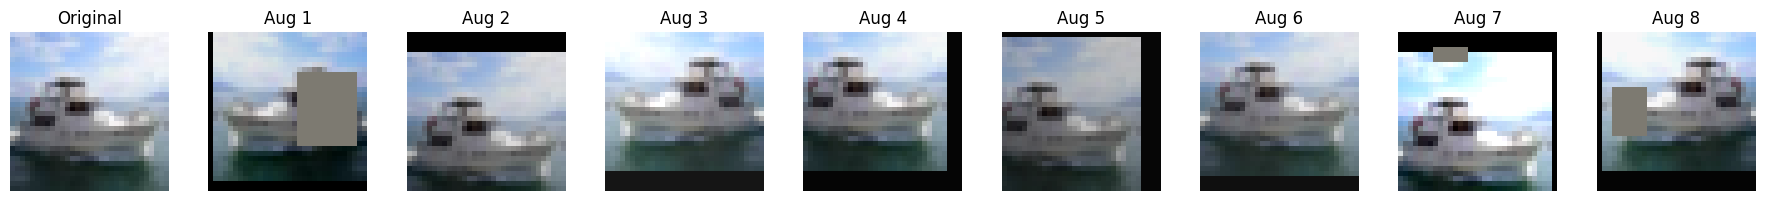

Showing different images from VALIDATION set (no augmentation):


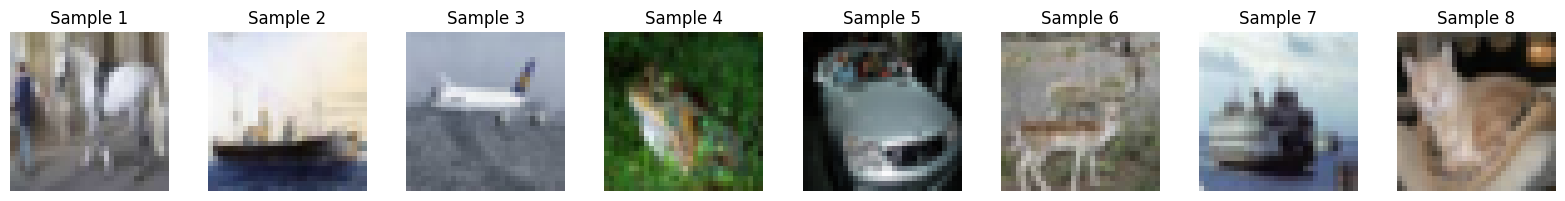

In [5]:

# Helper: denormalize for display
def denormalize(tensor, mean, std):
    """Denormalize a tensor for visualization."""
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return torch.clamp(tensor, 0, 1)

# Helper: show augmented samples
def show_augmented_samples(dataset, num_samples=8, same_image=True):
    """Show multiple augmented versions of the same image or different images."""
    transform = getattr(dataset, "transform", None)
    if transform is None:
        raise ValueError("Dataset has no transform set for augmentation display.")

    if same_image:
        original_dataset = torchvision.datasets.CIFAR10(
            root='./data', train=True, download=False, transform=None
        )
        idx = np.random.randint(0, len(original_dataset))
        original_img, label = original_dataset[idx]

        images = []
        for _ in range(num_samples):
            img_tensor = transform(original_img)
            img_denorm = denormalize(img_tensor, CIFAR10_MEAN, CIFAR10_STD)
            images.append(img_denorm)

        original_tensor = transforms.ToTensor()(original_img)
        images = [original_tensor] + images
    else:
        indices = np.random.choice(len(dataset), num_samples, replace=False)
        images = []
        for idx in indices:
            img, _ = dataset[idx]
            img_denorm = denormalize(img, CIFAR10_MEAN, CIFAR10_STD)
            images.append(img_denorm)

    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2))
    if n == 1:
        axes = [axes]

    for idx, (img, ax) in enumerate(zip(images, axes)):
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.set_title("Original" if idx == 0 and same_image else (f"Aug {idx}" if same_image else f"Sample {idx+1}"))
        ax.axis('off')

    plt.tight_layout()
    plt.show()

print("Showing multiple augmentations of the SAME image:")
show_augmented_samples(train_dataset, num_samples=8, same_image=True)

print("Showing different images from VALIDATION set (no augmentation):")
show_augmented_samples(val_dataset, num_samples=8, same_image=False)


## 2. Custom Transformations

Creating custom transformations allows you to implement domain-specific augmentation, combine operations, or add conditional logic.


### 2.1 Simple Custom Transformation


In [6]:
class AddGaussianNoise:
    """Add Gaussian noise to an image tensor."""

    def __init__(self, mean=0.0, std=0.1):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        noise = torch.randn_like(tensor) * self.std + self.mean
        noisy_tensor = tensor + noise
        return torch.clamp(noisy_tensor, 0, 1)

    def __repr__(self):
        return f"{self.__class__.__name__}(mean={self.mean}, std={self.std})"

custom_transform = transforms.Compose([
    transforms.ToTensor(),
    AddGaussianNoise(mean=0.0, std=0.05),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
])

print("Custom transformation: AddGaussianNoise")
print(custom_transform)


Custom transformation: AddGaussianNoise
Compose(
    ToTensor()
    AddGaussianNoise(mean=0.0, std=0.05)
    Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.247, 0.2435, 0.2616])
)


### 2.2 Advanced Custom Transformation (Cutout)


Custom transformation: Cutout
Compose(
    ToTensor()
    Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.247, 0.2435, 0.2616])
    Cutout(n_holes=1, length=16)
)
Visualizing Cutout transformation:


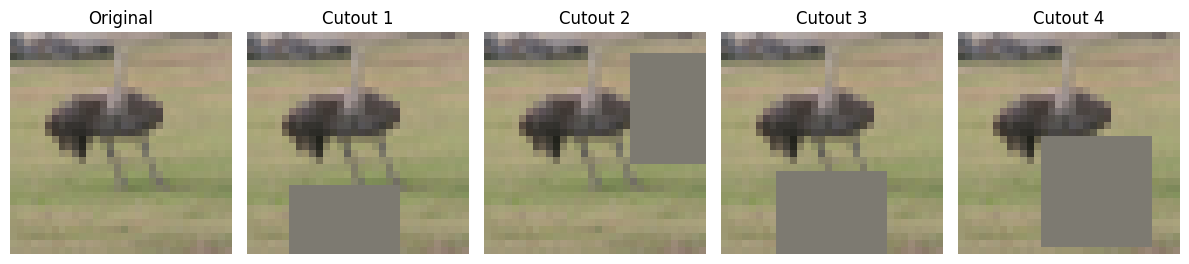

In [7]:
class Cutout:
    """Randomly mask out square regions of the image."""

    def __init__(self, n_holes=1, length=16):
        self.n_holes = n_holes
        self.length = length

    def __call__(self, img):
        h, w = img.size(1), img.size(2)
        mask = torch.ones((h, w), dtype=torch.float32)

        for _ in range(self.n_holes):
            y = np.random.randint(h)
            x = np.random.randint(w)
            y1 = np.clip(y - self.length // 2, 0, h)
            y2 = np.clip(y + self.length // 2, 0, h)
            x1 = np.clip(x - self.length // 2, 0, w)
            x2 = np.clip(x + self.length // 2, 0, w)
            mask[y1:y2, x1:x2] = 0.0

        mask = mask.expand_as(img)
        return img * mask

    def __repr__(self):
        return f"{self.__class__.__name__}(n_holes={self.n_holes}, length={self.length})"

cutout_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
    Cutout(n_holes=1, length=16),
])

print("Custom transformation: Cutout")
print(cutout_transform)

print("Visualizing Cutout transformation:")
cutout_demo_dataset = torchvision.datasets.CIFAR10(
    root=data_root, train=True, download=False, transform=None
)
img, label = cutout_demo_dataset[42]

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis('off')

for i in range(1, 5):
    img_tensor = cutout_transform(img)
    img_denorm = denormalize(img_tensor, CIFAR10_MEAN, CIFAR10_STD)
    axes[i].imshow(img_denorm.permute(1, 2, 0))
    axes[i].set_title(f"Cutout {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


### 2.3 Conditional Custom Transformation


In [8]:
class RandomTransformChoice:
    """Randomly choose one transformation from a list."""

    def __init__(self, transforms_list):
        self.transforms = transforms_list

    def __call__(self, img):
        transform = np.random.choice(self.transforms)
        return transform(img)

    def __repr__(self):
        format_string = self.__class__.__name__ + '('
        for t in self.transforms:
            format_string += f"{t}"
        format_string += ')'
        return format_string

random_choice_transform = RandomTransformChoice([
    transforms.ColorJitter(brightness=0.5),
    transforms.RandomRotation(15),
    transforms.GaussianBlur(kernel_size=5),
])

print("Random choice transformation:")
print(random_choice_transform)


Random choice transformation:
RandomTransformChoice(ColorJitter(brightness=(0.5, 1.5), contrast=None, saturation=None, hue=None)RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)GaussianBlur(kernel_size=(5, 5), sigma=(0.1, 2.0)))


## 3. Integration with DataLoader


### 3.1 Creating DataLoaders


In [9]:


batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

train_loader_no_aug = DataLoader(
    train_dataset_no_aug,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print(f"Training batches (aug): {len(train_loader)}")
print(f"Training batches (no aug): {len(train_loader_no_aug)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Batch size: {batch_size}")


Training batches (aug): 391
Training batches (no aug): 391
Validation batches: 391
Test batches: 79
Batch size: 128


### 3.2 Visualizing Batches


Training batch (with augmentation):


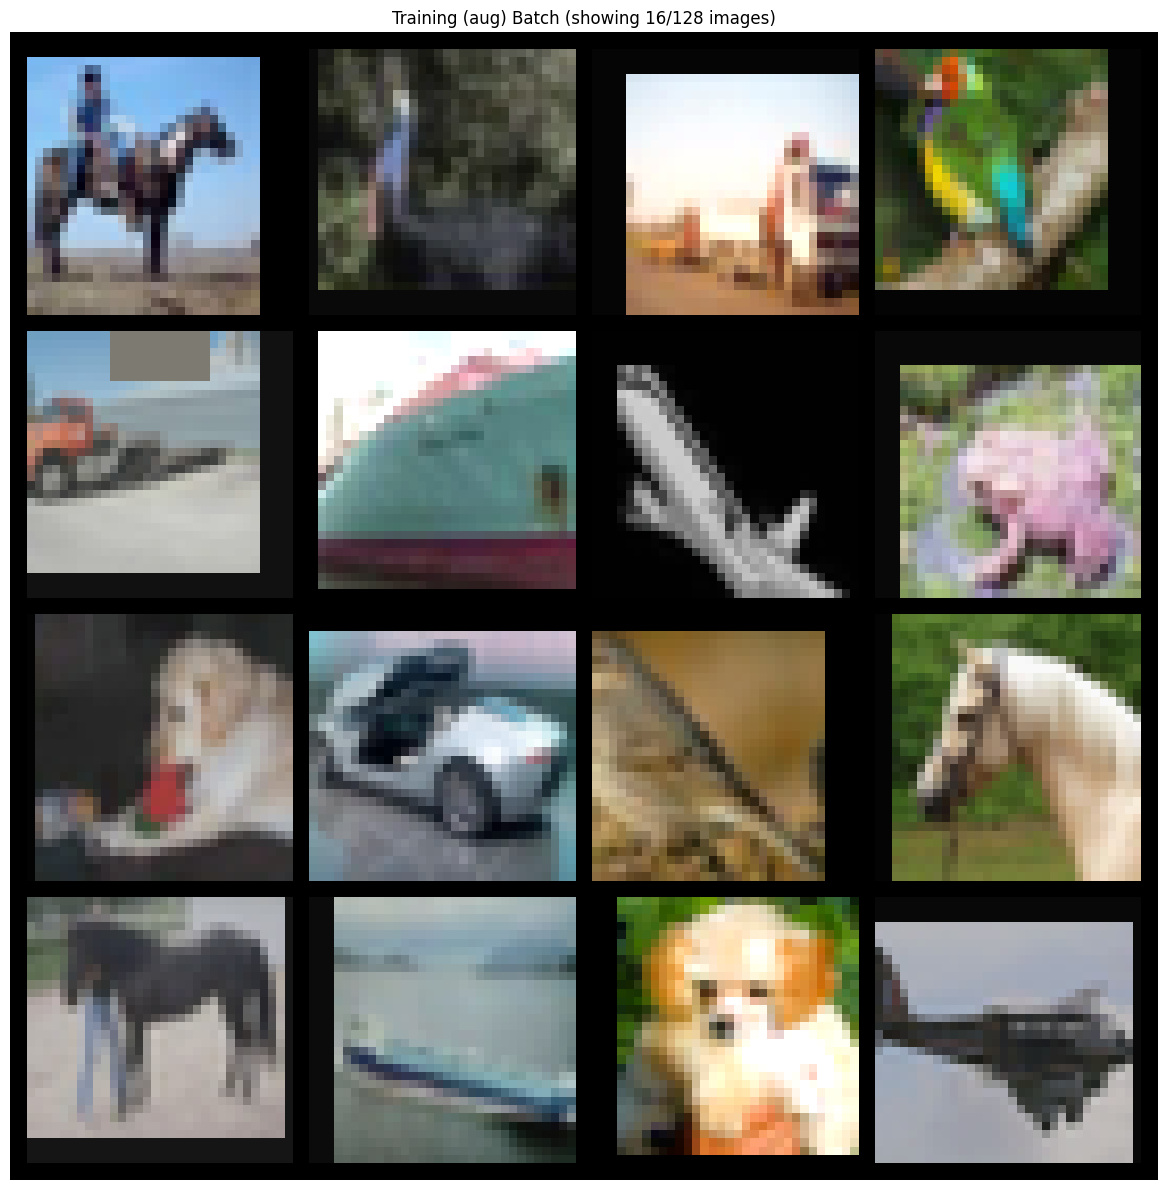

Labels for first 16 images:
['horse', 'bird', 'truck', 'bird', 'truck', 'ship', 'airplane', 'frog', 'dog', 'automobile', 'bird', 'horse', 'horse', 'ship', 'dog', 'airplane']
Training batch (no augmentation):


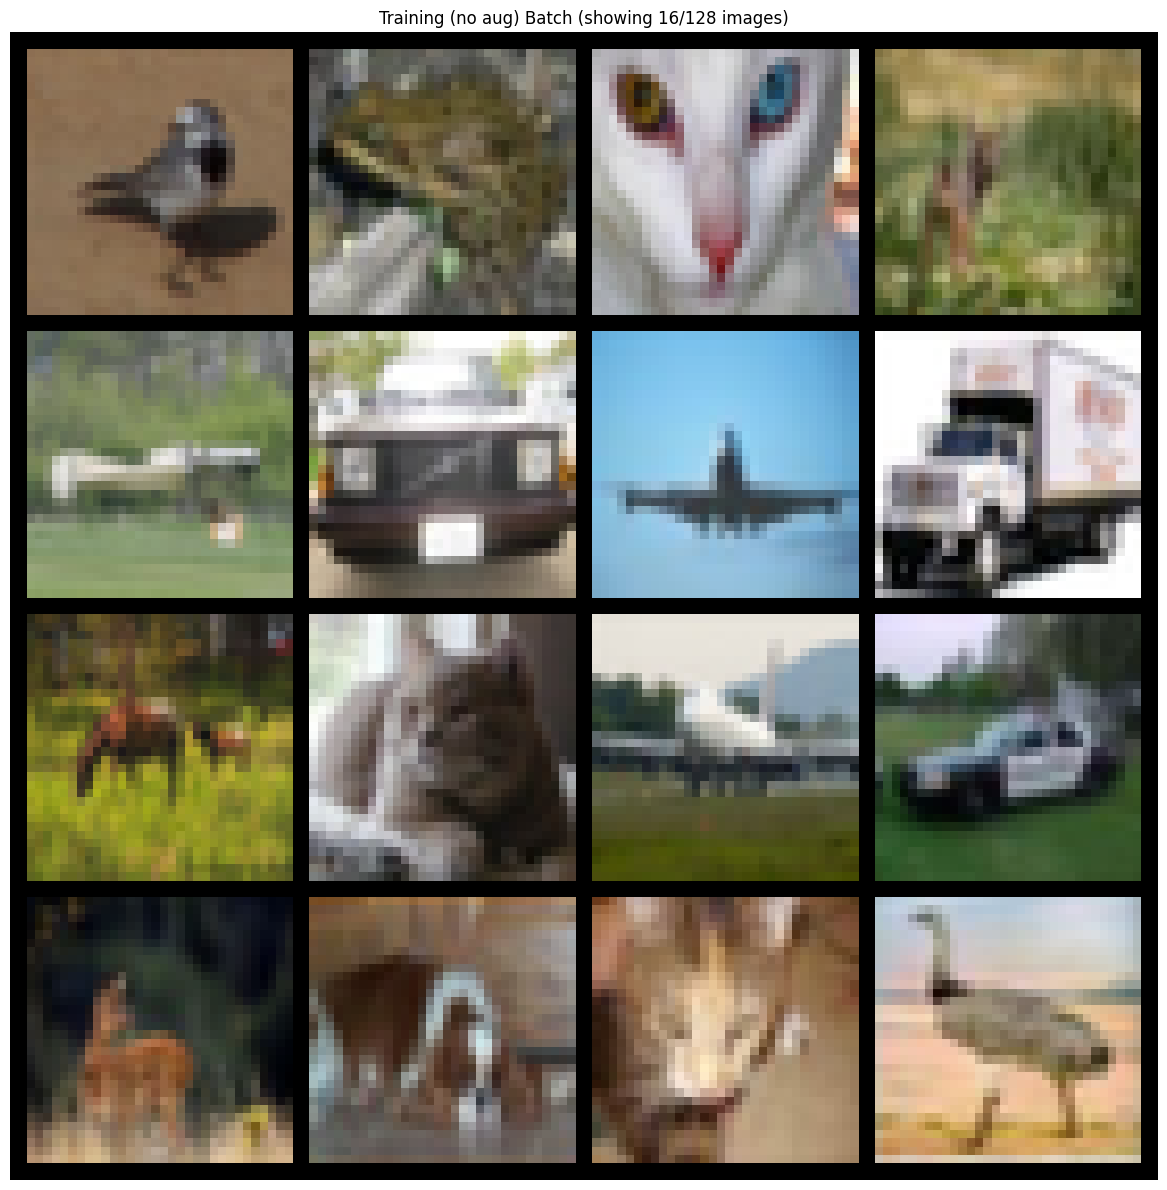

Labels for first 16 images:
['bird', 'frog', 'cat', 'deer', 'airplane', 'automobile', 'airplane', 'truck', 'horse', 'cat', 'airplane', 'automobile', 'deer', 'dog', 'cat', 'bird']
Validation batch (no augmentation):


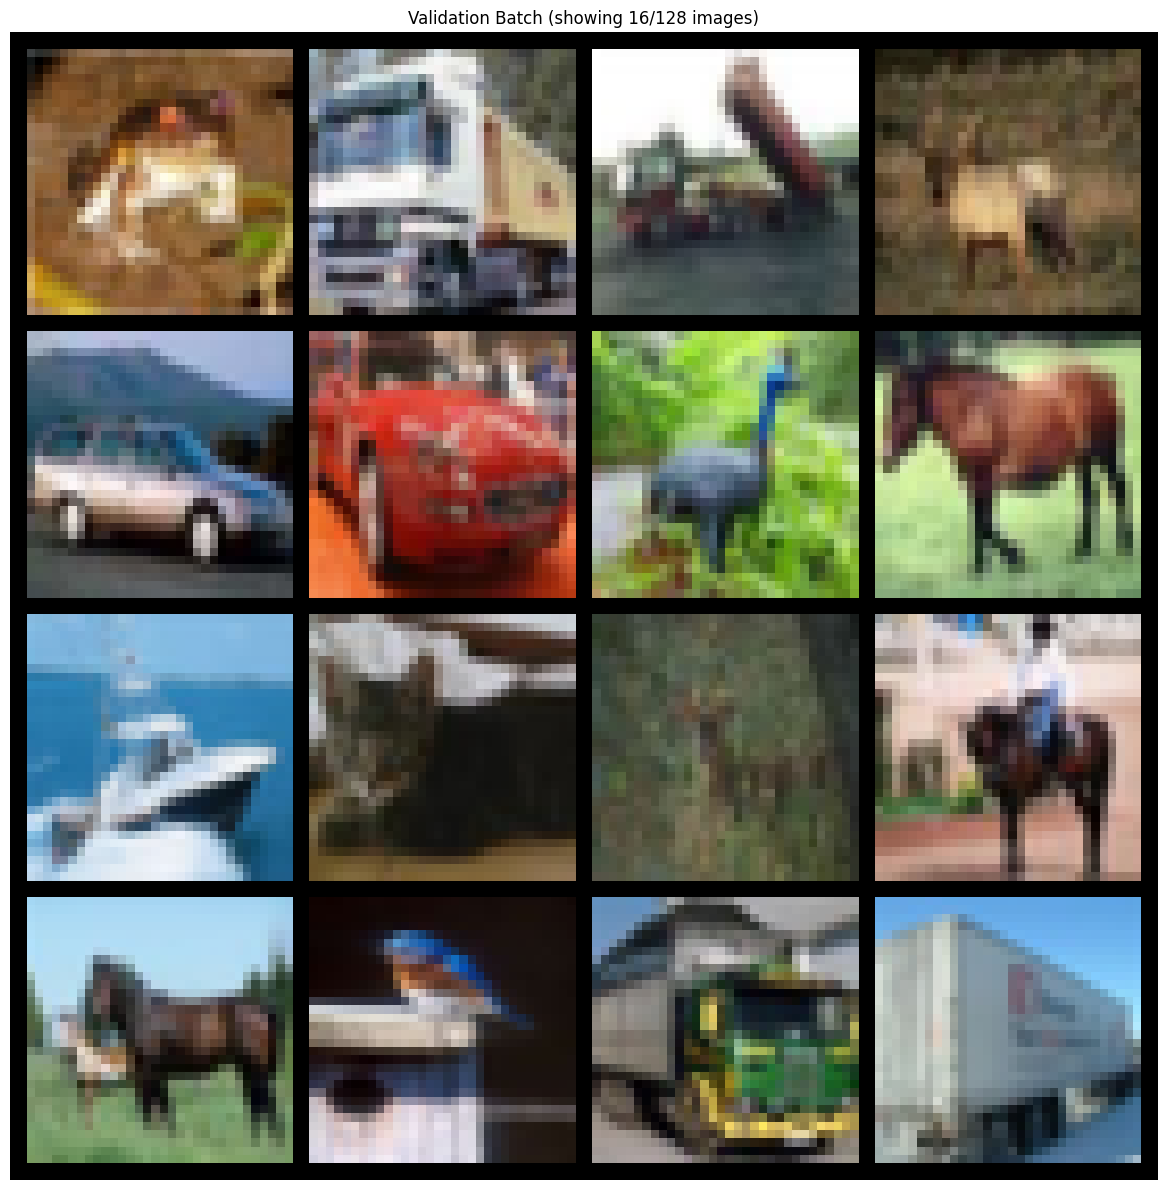

Labels for first 16 images:
['frog', 'truck', 'truck', 'deer', 'automobile', 'automobile', 'bird', 'horse', 'ship', 'cat', 'deer', 'horse', 'horse', 'bird', 'truck', 'truck']


In [10]:

def show_batch(loader, dataset_name="Dataset", num_images=16):
    images, labels = next(iter(loader))

    images_denorm = torch.stack([
        denormalize(img, CIFAR10_MEAN, CIFAR10_STD) for img in images[:num_images]
    ])

    grid = torchvision.utils.make_grid(images_denorm, nrow=4, padding=2)

    plt.figure(figsize=(12, 12))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(f"{dataset_name} Batch (showing {num_images}/{len(images)} images)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    class_names = train_dataset.classes
    print(f"Labels for first {num_images} images:")
    print([class_names[label] for label in labels[:num_images].tolist()])

print("Training batch (with augmentation):")
show_batch(train_loader, "Training (aug)", num_images=16)

print("Training batch (no augmentation):")
show_batch(train_loader_no_aug, "Training (no aug)", num_images=16)

print("Validation batch (no augmentation):")
show_batch(val_loader, "Validation", num_images=16)


### 3.3 Performance Considerations

Tips for optimizing data loading:
1. Use `num_workers` > 0 for parallel loading.
2. Use `pin_memory=True` when training on GPU.
3. Keep transforms lightweight.
4. Consider caching preprocessed data for validation.
5. Use `persistent_workers=True` for long training jobs.


In [11]:
def benchmark_dataloader(loader, num_batches=50):
    """Measure data loading speed."""
    start_time = time.time()
    for i, (images, labels) in enumerate(loader):
        if i >= num_batches:
            break
    elapsed = time.time() - start_time
    images_per_sec = (num_batches * loader.batch_size) / elapsed
    return elapsed, images_per_sec

print("Benchmarking data loading speed...")
train_time, train_speed = benchmark_dataloader(train_loader, num_batches=50)
print(f"Training loader: {train_time:.2f}s for 50 batches")
print(f"Speed: {train_speed:.0f} images/second")

val_time, val_speed = benchmark_dataloader(val_loader, num_batches=50)
print(f"Validation loader: {val_time:.2f}s for 50 batches")
print(f"Speed: {val_speed:.0f} images/second")


Benchmarking data loading speed...
Training loader: 15.24s for 50 batches
Speed: 420 images/second
Validation loader: 14.68s for 50 batches
Speed: 436 images/second


## 4. Best Practices and Guidelines

DATA AUGMENTATION BEST PRACTICES:

1. **Start conservative, increase gradually**: begin minimal, increase if overfitting (train >> val accuracy).
2. **Match augmentation to your problem**: e.g., object classification (RandomResizedCrop, flip), fine-grained (less aggressive), medical (careful with color), satellite (allow vertical flips/rotations).
3. **Normalization is critical**: always normalize; use ImageNet stats for transfer learning or dataset-specific stats; same normalization for train/val.
4. **Common augmentation strengths**:
   - Small datasets (<10K): stronger (ColorJitter(0.4,0.4,0.4,0.1), RandomErasing p≈0.3, maybe mixup/cutmix).
   - Medium (10K–100K): moderate (ColorJitter ≈0.3, RandomErasing p≈0.2).
   - Large (>100K): conservative (ColorJitter ≈0.2, RandomErasing p≈0.1).
5. **Validation rules**: never augment val/test, use deterministic transforms, same normalization, consistent preprocessing.
6. **Debugging augmentation**: visualize often, check aggressiveness, ensure labels still make sense, monitor training dynamics.
7. **Performance optimization**: multiple workers, `pin_memory`, cache validation, profile bottlenecks.
8. **Advanced techniques**: AutoAugment/RandAugment, MixUp/CutMix, learned augmentation policies, tune augmentation strength.


# Practical Example: Complete Training Pipeline


### Augmentation vs. No-Augmentation Training

We train two SimpleCNN models with identical hyperparameters. One uses the augmentation pipeline, the other only applies tensor conversion and normalization. We store their histories separately to compare train/validation curves and final test accuracy side by side.

Models will train on device: cpu
Number of parameters: 2,122,186

=== Training with Augmented data ===
Epoch 1/10 - Train Loss: 1.8302, Train Acc: 32.51% | Val Loss: 1.4445, Val Acc: 47.72%
Epoch 2/10 - Train Loss: 1.5062, Train Acc: 44.74% | Val Loss: 1.2586, Val Acc: 54.71%
Epoch 3/10 - Train Loss: 1.3538, Train Acc: 51.03% | Val Loss: 1.1011, Val Acc: 60.77%
Epoch 4/10 - Train Loss: 1.2355, Train Acc: 55.63% | Val Loss: 0.9903, Val Acc: 64.75%
Epoch 5/10 - Train Loss: 1.1597, Train Acc: 58.83% | Val Loss: 0.9378, Val Acc: 67.16%
Epoch 6/10 - Train Loss: 1.1070, Train Acc: 60.57% | Val Loss: 0.9059, Val Acc: 68.45%
Epoch 7/10 - Train Loss: 1.0593, Train Acc: 62.51% | Val Loss: 0.8156, Val Acc: 71.54%
Epoch 8/10 - Train Loss: 1.0117, Train Acc: 64.63% | Val Loss: 0.7700, Val Acc: 73.54%
Epoch 9/10 - Train Loss: 0.9821, Train Acc: 65.67% | Val Loss: 0.7870, Val Acc: 72.62%
Epoch 10/10 - Train Loss: 0.9613, Train Acc: 66.38% | Val Loss: 0.7386, Val Acc: 74.29%
Augmented - Test Loss: 0.7

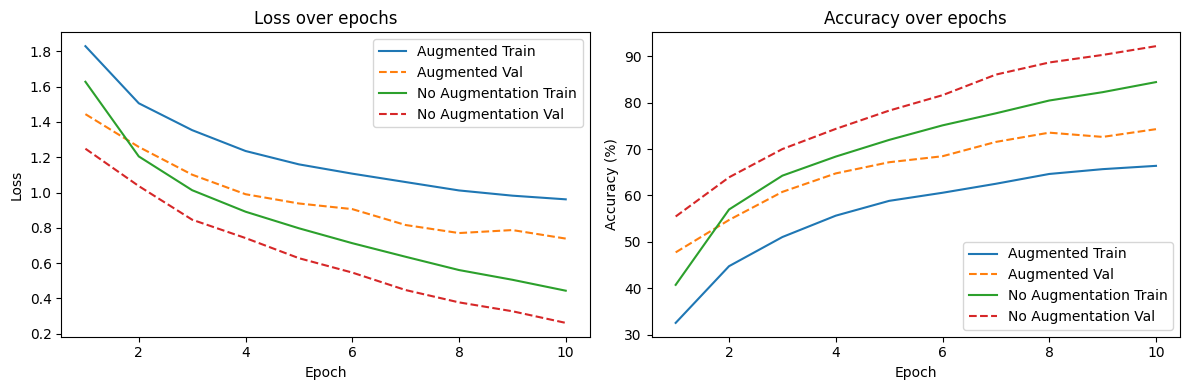


Test accuracy comparison:
       Augmented: loss=0.7772, acc=73.57%
 No Augmentation: loss=0.7573, acc=75.18%

Computing confusion matrix on test set (Augmented)...


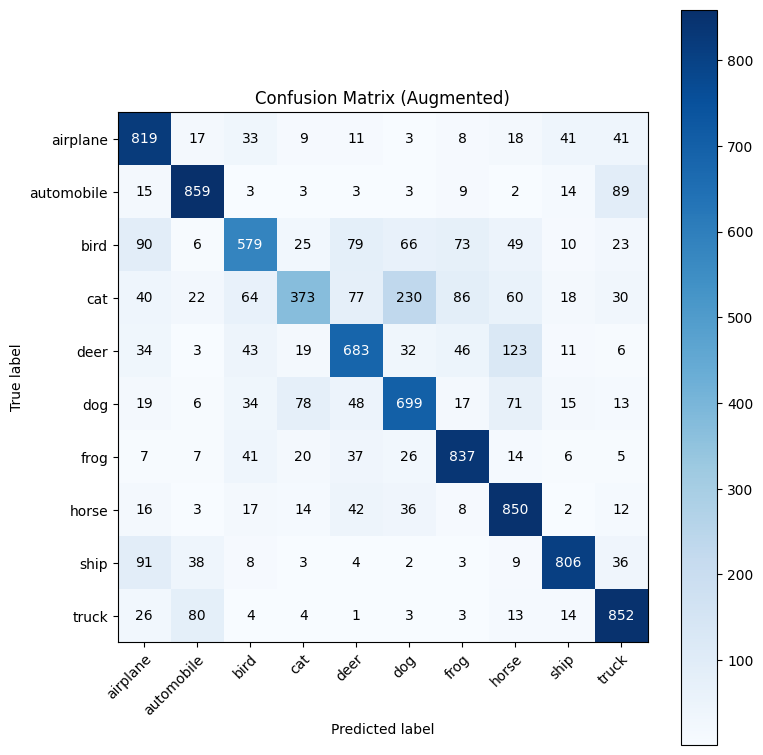


Computing confusion matrix on test set (No Augmentation)...


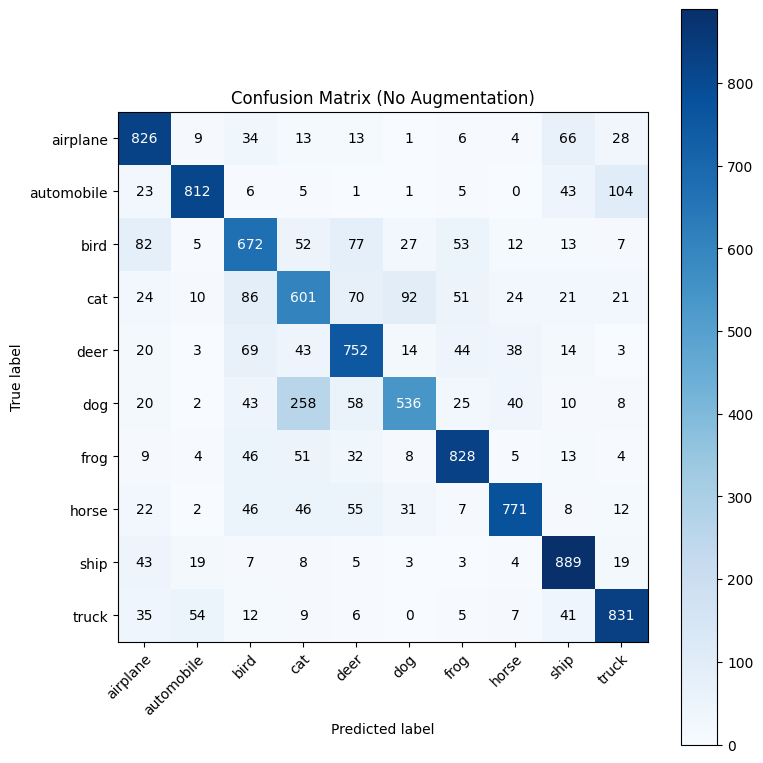

In [12]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


def init_model(num_classes, device):
    model = SimpleCNN(num_classes=num_classes).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    return model, optimizer


num_classes = 10
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
param_count = sum(p.numel() for p in SimpleCNN(num_classes=num_classes).parameters())

print(f"Models will train on device: {device}")
print(f"Number of parameters: {param_count:,}")

criterion = nn.CrossEntropyLoss()


def run_epoch(model, loader, criterion, optimizer=None, device='cpu', max_batches=None):
    """Run one epoch. If optimizer is None, runs in eval mode."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss, correct, total = 0.0, 0, 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            outputs = model(images)
            loss = criterion(outputs, labels)
            if is_train:
                loss.backward()
                optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if max_batches is not None and batch_idx + 1 >= max_batches:
            break

    epoch_loss = running_loss / (batch_idx + 1)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def train_and_validate(model, train_loader, val_loader, criterion, optimizer, device, epochs=5, max_batches_per_epoch=None):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, device, max_batches=max_batches_per_epoch)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None, device=device, max_batches=max_batches_per_epoch)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch}/{epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    return history


def plot_histories(histories):
    epochs = range(1, len(next(iter(histories.values()))["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for label, history in histories.items():
        axes[0].plot(epochs, history["train_loss"], label=f"{label} Train")
        axes[0].plot(epochs, history["val_loss"], linestyle='--', label=f"{label} Val")
        axes[1].plot(epochs, history["train_acc"], label=f"{label} Train")
        axes[1].plot(epochs, history["val_acc"], linestyle='--', label=f"{label} Val")

    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss over epochs')
    axes[0].legend()

    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Accuracy over epochs')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def compute_confusion_matrix(model, loader, device, num_classes):
    conf_mat = torch.zeros((num_classes, num_classes), dtype=torch.int64)
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            for t, p in zip(labels.view(-1), preds.view(-1)):
                conf_mat[t.long(), p.long()] += 1
    return conf_mat.cpu().numpy()


def plot_confusion_matrix(conf_mat, class_names, title_suffix=""):
    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(conf_mat, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)

    ax.set(xticks=range(len(class_names)), yticks=range(len(class_names)),
           xticklabels=class_names, yticklabels=class_names,
           xlabel='Predicted label', ylabel='True label', title=f'Confusion Matrix {title_suffix}')

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    thresh = conf_mat.max() / 2.
    for i in range(conf_mat.shape[0]):
        for j in range(conf_mat.shape[1]):
            ax.text(j, i, format(conf_mat[i, j], 'd'), ha="center", va="center",
                    color="white" if conf_mat[i, j] > thresh else "black")

    plt.tight_layout()
    plt.show()


# === Run training/validation for both setups ===
num_epochs = 10
max_batches_per_epoch = None  # set to a small int (e.g., 50) for faster demo runs

experiments = [
    ("Augmented", train_loader),
    ("No Augmentation", train_loader_no_aug),
]

histories = {}
trained_models = {}
test_metrics = {}

for label, loader in experiments:
    print(f"\n=== Training with {label} data ===")
    torch.manual_seed(42)
    np.random.seed(42)

    model, optimizer = init_model(num_classes=num_classes, device=device)
    history = train_and_validate(
        model,
        loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=num_epochs,
        max_batches_per_epoch=max_batches_per_epoch,
    )

    histories[label] = history
    trained_models[label] = model

    test_loss, test_acc = run_epoch(
        model,
        test_loader,
        criterion,
        optimizer=None,
        device=device,
        max_batches=None,
    )
    test_metrics[label] = {"test_loss": test_loss, "test_acc": test_acc}
    print(f"{label} - Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

plot_histories(histories)

print("\nTest accuracy comparison:")
for label, metrics in test_metrics.items():
    print(f"{label:>16}: loss={metrics['test_loss']:.4f}, acc={metrics['test_acc']:.2f}%")

for label, model in trained_models.items():
    print(f"\nComputing confusion matrix on test set ({label})...")
    conf_mat = compute_confusion_matrix(model, test_loader, device, num_classes=num_classes)
    plot_confusion_matrix(conf_mat, class_names=train_dataset.classes, title_suffix=f"({label})")


> **Importante note**: with short training, augmentation can look worse because it delays early convergence, even though it typically improves generalization with sufficient training.

### Why might the no-augmentation run look better (early epochs)?

- Augmentation is relatively strong for a small CNN + short training: RandomCrop + ColorJitter + RandomErasing reduce signal and make SGD progress slower; in only 10 epochs the model may not reap the robustness benefits.
- Undertraining: with augmentation the gradient is noisier, so it needs more epochs (e.g., 20–30) to match/beat the baseline.
- Hyperparameters not tuned for augmentation: SGD (lr=0.01, momentum=0.9) without a scheduler can plateau when the data is harder.
- This isn’t data leakage (val/test are unaugmented); the apparent gain is likely mild overfitting + slower convergence with aug.
- Single-seed variance: one seed can favor one setup; multiple seeds help confirm.

Ideas for follow-up experiments:
1) Train longer (20–30 epochs) and check if the augmented run overtakes the baseline; for quick tests, cap `max_batches_per_epoch`.
2) Soften augmentation: reduce/remove ColorJitter (e.g., 0.1) and/or RandomErasing (p≈0.1 or off) and see if the gap closes.
3) Add a simple LR schedule (StepLR/OneCycle) or try a slightly higher initial LR (e.g., 0.02) for the augmented run.
4) Repeat with 3–5 random seeds to gauge stability.

# Key Takeaways - Part 3

1. **Pipeline design**: training = augmentation + normalization; validation = deterministic preprocessing + same normalization; adapt to image size.
2. **Custom transforms**: implement `__call__`/`__repr__` for domain-specific augmentation.
3. **DataLoader integration**: transforms applied at load time; use workers/pin_memory; always visualize batches.
4. **Best practices**: start conservative, match domain, normalize consistently, never augment validation.
5. **Debugging/performance**: visualize often, monitor aggressiveness, benchmark data loading, consider advanced policies (AutoAugment, MixUp/CutMix).
